# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re

import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/andri/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/andri/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [16]:
dataset_path = "../ASAP2_train_sourcetexts.csv"
df = pd.read_csv(dataset_path)

df.head()

,essay_id,score,full_text,assignment,prompt_name,economically_disadvantaged,student_disability_status,ell_status,race_ethnicity,gender,source_text_1,source_text_2,source_text_3,source_text_4
0,AAAVUP14319000159574,4,The author suggests that studying Venus is wor...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Identified as having disability,No,Black/African American,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
1,AAAVUP14319000159542,2,NASA is fighting to be alble to to go to Venus...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Not economically disadvantaged,Not identified as having disability,No,Hispanic/Latino,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
2,AAAVUP14319000159461,3,"""The Evening Star"", is one of the brightest po...","In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Identified as having disability,No,White,M,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
3,AAAVUP14319000159420,2,The author supports this idea because from rea...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Not identified as having disability,Yes,Hispanic/Latino,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
4,AAAVUP14319000159419,2,How the author supports this idea is that he s...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Not identified as having disability,Yes,Hispanic/Latino,M,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

<class 'pandas.DataFrame'>
RangeIndex: 24728 entries, 0 to 24727
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   essay_id                    24728 non-null  str  
 1   score                       24728 non-null  int64
 2   full_text                   24728 non-null  str  
 3   assignment                  24728 non-null  str  
 4   prompt_name                 24728 non-null  str  
 5   economically_disadvantaged  20723 non-null  str  
 6   student_disability_status   20723 non-null  str  
 7   ell_status                  24286 non-null  str  
 8   race_ethnicity              24724 non-null  str  
 9   gender                      24728 non-null  str  
 10  source_text_1               24728 non-null  str  
 11  source_text_2               4005 non-null   str  
 12  source_text_3               4005 non-null   str  
 13  source_text_4               1959 non-null   str  
dtypes: int64(1), str(

/tmp/ipykernel_39287/335655280.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=score_value, y=score_counts, palette='viridis')


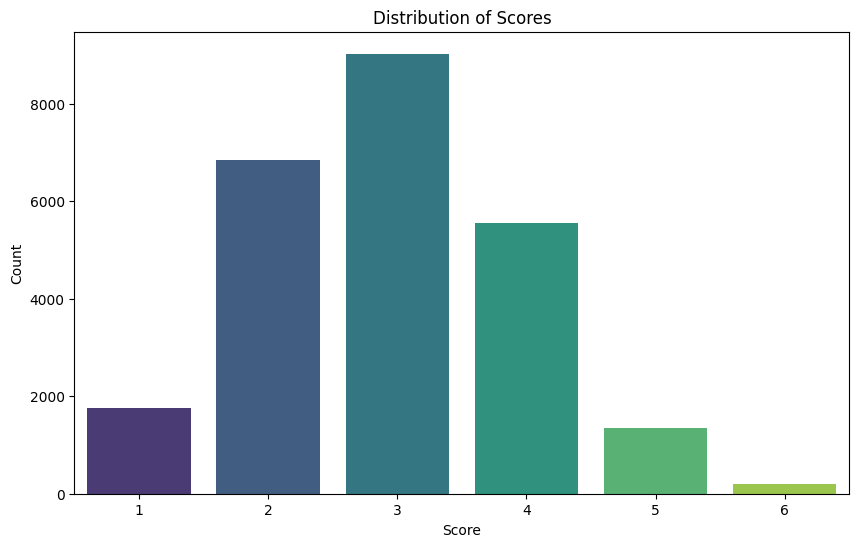

In [17]:
df.info()
df.describe()

score_counts = df['score'].value_counts()
score_value = df['score'].value_counts().index

# Visualize the distribution of scores
plt.figure(figsize=(10, 6))
sns.barplot(x=score_value, y=score_counts, palette='viridis')
plt.title('Distribution of Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()



# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [18]:
# Menangani Missing Values
# ---------------------------------------------------------------
missing_values = df.isnull().sum()

less = missing_values[missing_values < 20000].index
over = missing_values[missing_values > 20000].index

df = df.drop(columns=over)

# mengisi missing values dengan Unknown
# ---------------------------------------------------------------
categorical_cols = df[less].select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Menghapus kolom yang tidak diperlukan
# ---------------------------------------------------------------
columns_to_drop = ['essay_id']
df = df.drop(columns=columns_to_drop)
df.info()


/tmp/ipykernel_39287/1832761969.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df[less].select_dtypes(include=['object']).columns


<class 'pandas.DataFrame'>
RangeIndex: 24728 entries, 0 to 24727
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   score                       24728 non-null  int64
 1   full_text                   24728 non-null  str  
 2   assignment                  24728 non-null  str  
 3   prompt_name                 24728 non-null  str  
 4   economically_disadvantaged  24728 non-null  str  
 5   student_disability_status   24728 non-null  str  
 6   ell_status                  24728 non-null  str  
 7   race_ethnicity              24728 non-null  str  
 8   gender                      24728 non-null  str  
 9   source_text_1               24728 non-null  str  
dtypes: int64(1), str(9)
memory usage: 1.9 MB


In [19]:
# Melakukan processing
# ---------------------------------------------------------------
 
def cleaning_text(text):
    text = re.sub(r'[^\w\s]', '', text)
    text = text.replace('\n', ' ')
    text = text.strip()
    return text

def case_folding(text):
    return text.lower()

def tokenization(text):
    return text.split()

def remove_stopwords(tokens):
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return filtered_tokens

def to_sentences(tokens):
    return ' '.join(tokens)


def preprocess_text(text):
    cleaned_text = cleaning_text(text)
    folded_text = case_folding(cleaned_text)
    tokens = tokenization(folded_text)
    filtered_tokens = remove_stopwords(tokens)
    final_text = to_sentences(filtered_tokens)
    return final_text

df['processed_text'] = df['full_text'].apply(preprocess_text)



In [20]:
df.head()

,score,full_text,assignment,prompt_name,economically_disadvantaged,student_disability_status,ell_status,race_ethnicity,gender,source_text_1,processed_text
0,4,The author suggests that studying Venus is wor...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Identified as having disability,No,Black/African American,F,"The Challenge of Exploring Venus\nVenus, somet...",author suggests studying venus worthy enough e...
1,2,NASA is fighting to be alble to to go to Venus...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Not economically disadvantaged,Not identified as having disability,No,Hispanic/Latino,F,"The Challenge of Exploring Venus\nVenus, somet...",nasa fighting alble go venus researching diffr...
2,3,"""The Evening Star"", is one of the brightest po...","In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Identified as having disability,No,White,M,"The Challenge of Exploring Venus\nVenus, somet...",evening star one brightest points light sky ni...
3,2,The author supports this idea because from rea...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Not identified as having disability,Yes,Hispanic/Latino,F,"The Challenge of Exploring Venus\nVenus, somet...",author supports idea reading passage suggests ...
4,2,How the author supports this idea is that he s...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Not identified as having disability,Yes,Hispanic/Latino,M,"The Challenge of Exploring Venus\nVenus, somet...",author supports idea states text strivivng mee...


/tmp/ipykernel_39287/492673874.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='score_label', data=df, palette='viridis')


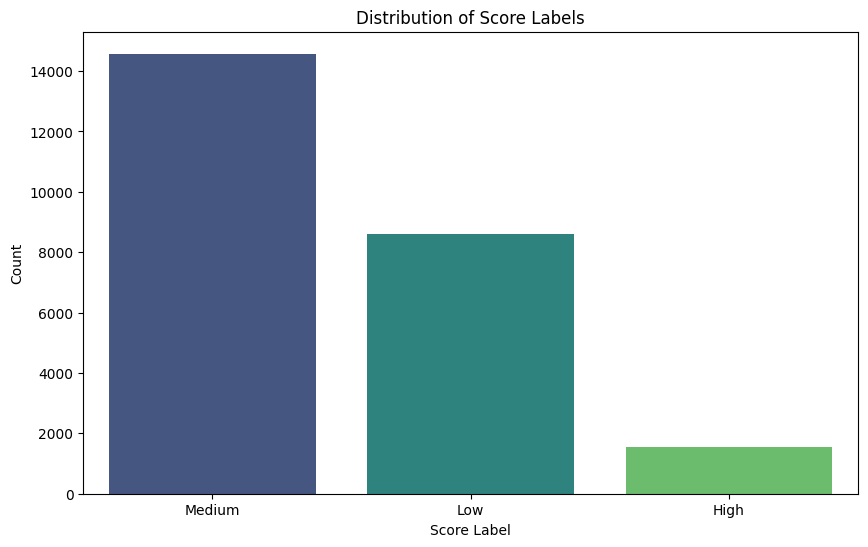

In [21]:
# pelabelan data
# ---------------------------------------------------------------
def label_score(score):
    if score <= 2:
        return 'Low'
    elif score <= 4:
        return 'Medium'
    else:
        return 'High'
    

df['score_label'] = df['score'].apply(label_score)
df.head()

plt.figure(figsize=(10, 6))
sns.countplot(x='score_label', data=df, palette='viridis')
plt.title('Distribution of Score Labels')
plt.xlabel('Score Label')
plt.ylabel('Count')
plt.show()

In [22]:
# menyimpan dataset yang sudah diproses
processed_dataset_path = "ASAP2_train_sourcetexts_processed.csv"
df.to_csv(processed_dataset_path, index=False)
